##### DATA 620 - WEEK 3 PART 2
## Southern Women Social Network Analysis
**Author**
- Barakat Adigun

# Southern Women Social Network Analysis

## Objective

This assignment analyzes the Southern Women social network dataset included in NetworkX. The dataset represents attendance at social events by 18 women and 14 social events.

This is a bipartite network because there are two different types of nodes:

- Women
- Social Events

An edge exists when a woman attended an event.

The goal is to examine the relationships among both the women and the events by projecting the bipartite graph into one-mode networks.

In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
##Load Dataset

G = nx.davis_southern_women_graph()

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 32
Number of edges: 89


In [25]:
##Identify Node set

women = G.graph["top"]
events = G.graph["bottom"]

print("Number of women:", len(women))
print("Number of events:", len(events))

Number of women: 18
Number of events: 14


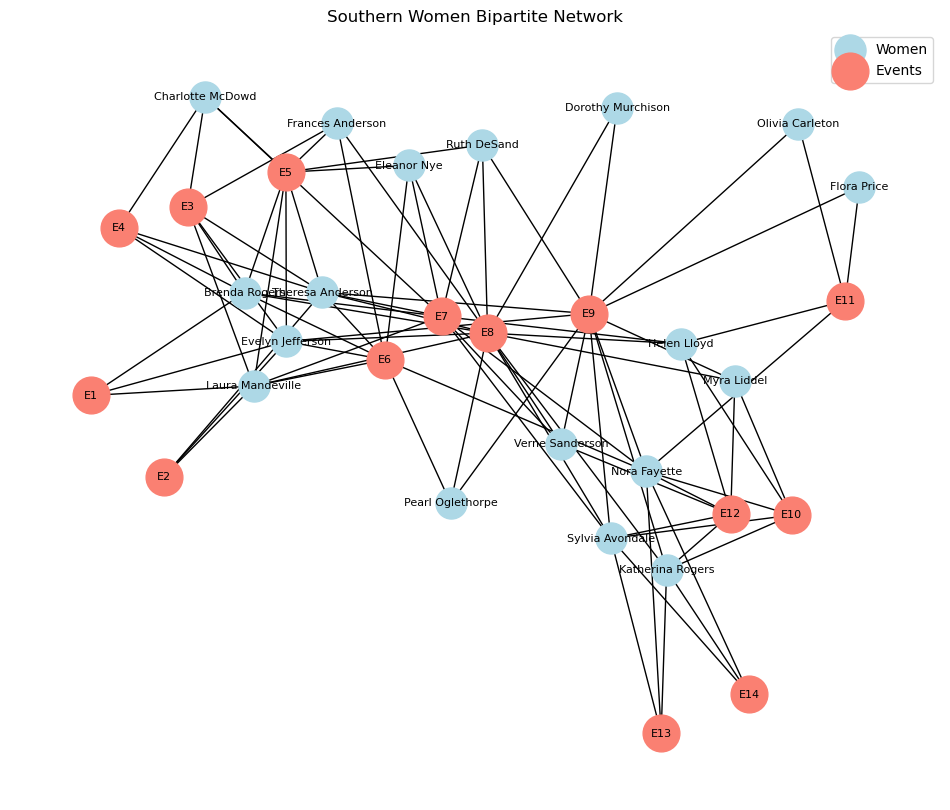

In [26]:
##Visualization

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=women,
    node_color="lightblue",
    node_size=500,
    label="Women"
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=events,
    node_color="salmon",
    node_size=700,
    label="Events"
)

nx.draw_networkx_edges(G,pos)
nx.draw_networkx_labels(G,pos,font_size=8)

plt.title("Southern Women Bipartite Network")
plt.legend()
plt.axis("off")
plt.show()

In [27]:
## Women Projection

women_graph = nx.bipartite.weighted_projected_graph(G, women)

print("Number of nodes:", women_graph.number_of_nodes())
print("Number of edges:", women_graph.number_of_edges())

Number of nodes: 18
Number of edges: 139


In [28]:
## Women Degree Centrality

degree = nx.degree_centrality(women_graph)

degree_df = pd.DataFrame(
    degree.items(),
    columns=["Woman","Degree Centrality"]
)

degree_df = degree_df.sort_values(
    by="Degree Centrality",
    ascending=False
)

degree_df

,Woman,Degree Centrality
0,Evelyn Jefferson,1.000000
8,Ruth DeSand,1.000000
14,Helen Lloyd,1.000000
13,Nora Fayette,1.000000
12,Sylvia Avondale,1.000000
9,Verne Sanderson,1.000000
2,Theresa Anderson,1.000000
7,Pearl Oglethorpe,0.941176
10,Myra Liddel,0.941176
11,Katherina Rogers,0.941176


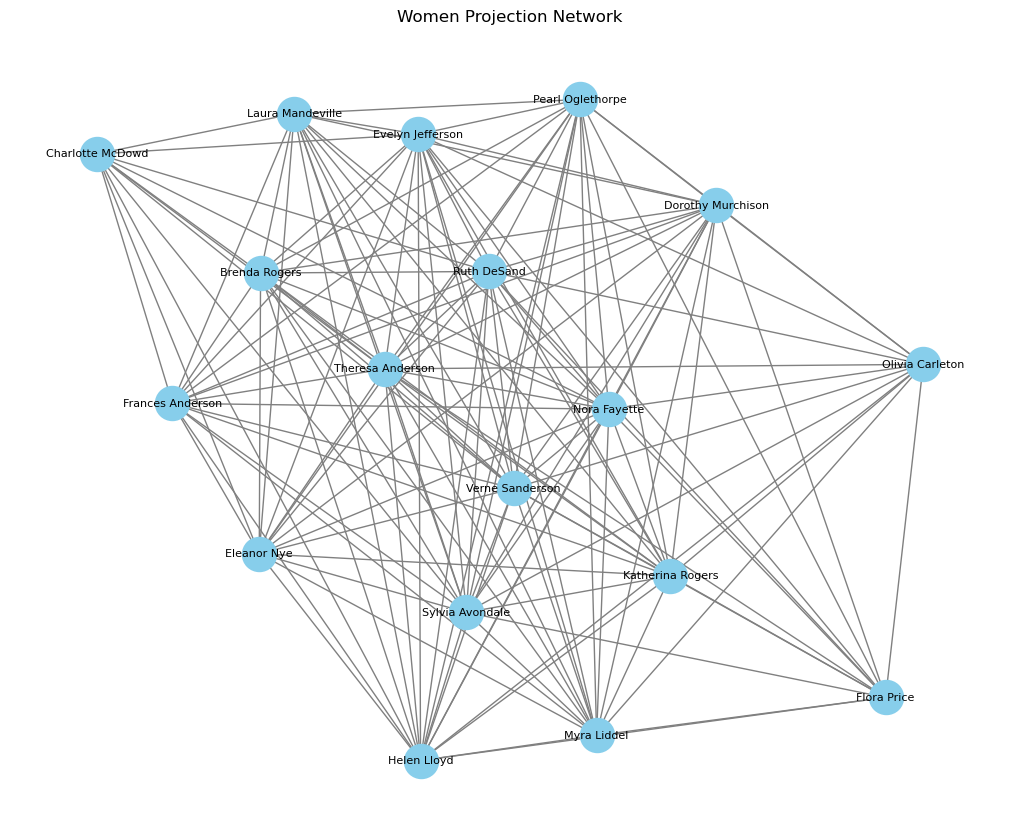

In [29]:
## Women's Network Visualization

plt.figure(figsize=(10,8))

pos = nx.spring_layout(women_graph, seed=42)

nx.draw(
    women_graph,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=600,
    edge_color="gray",
    font_size=8
)

plt.title("Women Projection Network")
plt.show()

In [30]:
## Event Projection

event_graph = nx.bipartite.weighted_projected_graph(G, events)

print("Number of nodes:", event_graph.number_of_nodes())
print("Number of edges:", event_graph.number_of_edges())

Number of nodes: 14
Number of edges: 66


In [31]:
## Event Degree Centrality

event_degree = nx.degree_centrality(event_graph)

event_df = pd.DataFrame(
    event_degree.items(),
    columns=["Event","Degree Centrality"]
)

event_df = event_df.sort_values(
    by="Degree Centrality",
    ascending=False
)

event_df

,Event,Degree Centrality
5,E6,1.000000
6,E7,1.000000
7,E8,1.000000
8,E9,1.000000
0,E1,0.615385
1,E2,0.615385
2,E3,0.615385
3,E4,0.615385
4,E5,0.615385
9,E10,0.615385


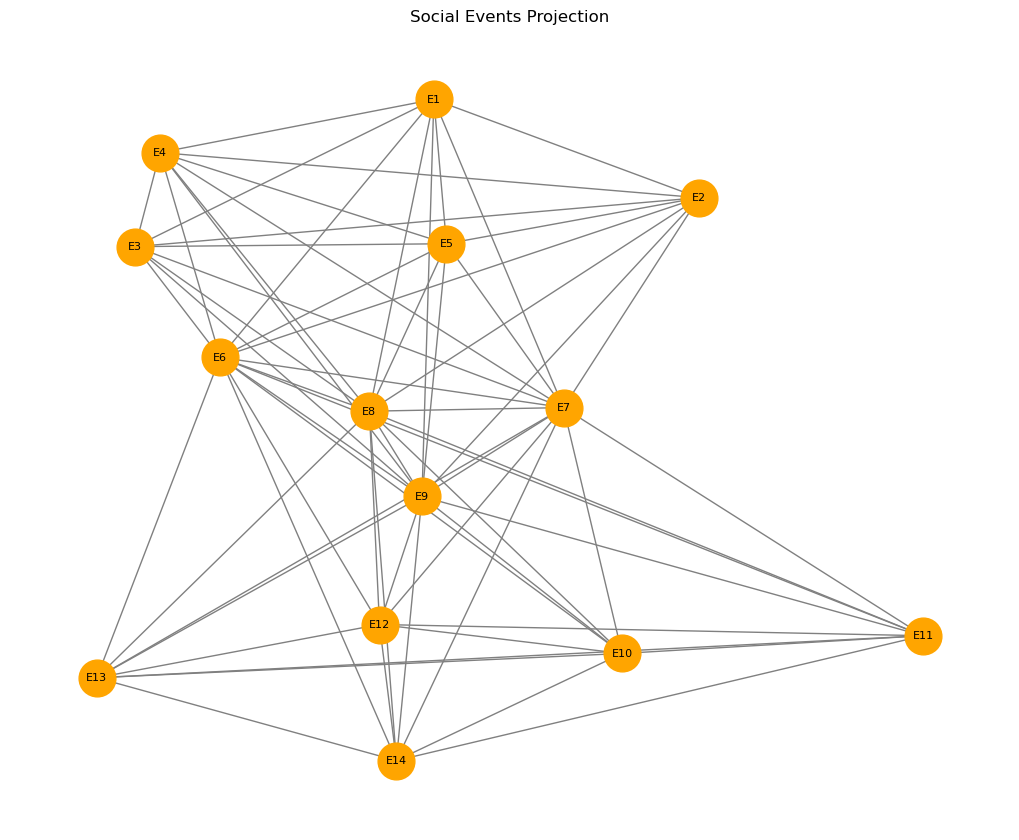

In [32]:
## Event Network Visualization

plt.figure(figsize=(10,8))

pos = nx.spring_layout(event_graph, seed=42)

nx.draw(
    event_graph,
    pos,
    with_labels=True,
    node_color="orange",
    node_size=700,
    edge_color="gray",
    font_size=8
)

plt.title("Social Events Projection")
plt.show()

In [33]:
## Shared Events Women Connection

women_adj = nx.to_pandas_adjacency(women_graph)

women_adj.head()

,Evelyn Jefferson,Laura Mandeville,Theresa Anderson,Brenda Rogers,Charlotte McDowd,Frances Anderson,Eleanor Nye,Pearl Oglethorpe,Ruth DeSand,Verne Sanderson,Myra Liddel,Katherina Rogers,Sylvia Avondale,Nora Fayette,Helen Lloyd,Dorothy Murchison,Olivia Carleton,Flora Price
Evelyn Jefferson,0.0,6.0,7.0,6.0,3.0,4.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0
Laura Mandeville,6.0,0.0,6.0,6.0,3.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,0.0,0.0
Theresa Anderson,7.0,6.0,0.0,6.0,4.0,4.0,4.0,3.0,4.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,1.0,1.0
Brenda Rogers,6.0,6.0,6.0,0.0,4.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,2.0,2.0,2.0,1.0,0.0,0.0
Charlotte McDowd,3.0,3.0,4.0,4.0,0.0,2.0,2.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [34]:
## Shared Attendees Events Conection

event_adj = nx.to_pandas_adjacency(event_graph)

event_adj.head()

,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14
E1,0.0,2.0,3.0,2.0,3.0,3.0,2.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0
E2,2.0,0.0,3.0,2.0,3.0,3.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0
E3,3.0,3.0,0.0,4.0,6.0,5.0,4.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0
E4,2.0,2.0,4.0,0.0,4.0,3.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0
E5,3.0,3.0,6.0,4.0,0.0,6.0,6.0,7.0,3.0,0.0,0.0,0.0,0.0,0.0


## Analysis

The bipartite network illustrates which women attended each social event. By projecting the network onto the women, two women become connected whenever they attended the same event.

Women with the highest degree centrality attended events with many different participants and therefore formed connections with a larger number of women. These individuals appear to be the most socially active members of the network and may serve as important connectors within the community.

The projection onto the event network links two events when they shared attendees. Events with high degree centrality attracted many of the same women who attended other gatherings, suggesting that these were popular community events that helped connect multiple social circles.

Overall, both projections reveal a highly connected social structure. Some women consistently participated across many events, while several events served as central meeting places that strengthened relationships throughout the network.

## Conclusion

The Southern Women dataset demonstrates how bipartite networks can be transformed into one-mode networks to better understand relationships.

Key findings include:

- Several women have much higher degree centrality than others, indicating greater social involvement.
- Some social events are considerably more central because they share many attendees with other events.
- The projections reveal overlapping friendship circles rather than isolated groups.
- Shared attendance patterns suggest a tightly connected social community where a relatively small number of women and events help connect the overall network.